In [11]:
using Pkg
Pkg.activate("../scripts/calval")
using IceFloeTracker
using Images
using DataFrames
using CSVFiles
using CairoMakie
using GLM
using StatsBase

  Activating project at `~/Documents/research/manuscripts/calval_tgrs/scripts/calval`


# Filter Floes
The filter floes function is designed to remove false positives prior to the "merge floes" step. To calibrate the filter floes function, we identify objects belong to no relevant sets based on the manually identified floes. This should give us quite a few shapes to work with.

In [5]:
dataset = Watkins2026Dataset(;
    url="https://github.com/danielmwatkins/ice-floe-validation-dataset/",
    ref="v0.2",
    cache_dir="/tmp/Watkins2026",
    metadata_path="data/validation_dataset/validation_dataset.csv",
)

#### Run this to use the previously defined test/train split ####
prior_data = DataFrame(load("../data/train_test_split.csv"))
dataset.info[:, :training_sample] = parse.(Bool, prior_data[:, :training_sample])
dataset.info[:, :testing_sample] = parse.(Bool, prior_data[:, :testing_sample])
train_cases = filter(c -> c.training_sample, dataset) 
test_cases = filter(c -> c.testing_sample, dataset);

train_cases.info[:, :lookup_index] = 1:nrow(train_cases.info)
test_cases.info[:, :lookup_index] = 1:nrow(test_cases.info);

cluster_algo = IceDetectionBrightnessPeaksMODIS721(;
        band_7_max=0.16,
        possible_ice_threshold=0.6,
        join_method="union",
        minimum_prominence=0.01,
    )

cleanup_binary_params = (erosion_strel=strel_box((3, 3)), init_max_fill=100, conditional_max_fill=500
)
floe_splitting_params = (max_hole_fill=2000, max_distance=5, max_expand=3)

function clean_split_label(binary_mask, ice_mask, cloud_mask)
    return FSPipeline.dist_morph_split(
        FSPipeline.clean_binary_floes(binary_mask, ice_mask, cloud_mask; cleanup_binary_params...);
        floe_splitting_params...,
    )
end

# Workflows produce labeled arrays, not segmented images
function kmeans_workflow(preproc_gray, fc_masked, water_mask, ice_mask, cloud_mask; k=4, cluster_selection_algorithm=cluster_algo)
    masked_gray = apply_landmask(preproc_gray, water_mask)
    kmeans_result = kmeans_binarization(
        masked_gray, fc_masked; k=k, cluster_selection_algorithm=cluster_algo) .> 0
    return clean_split_label(kmeans_result, ice_mask, cloud_mask)
end

function adaptive_workflow(preproc_gray, land_mask, water_mask, ice_mask, cloud_mask; window_size=400, percentage=0)
    adaptive_result = binarize(preproc_gray, AdaptiveThreshold(; window_size=window_size, percentage=percentage)) .> 0
    apply_landmask!(adaptive_result, land_mask)
    apply_landmask!(adaptive_result, water_mask)
    return clean_split_label(adaptive_result .> 0, ice_mask, cloud_mask)    
end

adaptive_workflow (generic function with 1 method)

In [6]:
case = train_cases

function fill_missing!(cases; template=Gray.(zeros(Bool, (400, 400))))
    for (idx, img) in enumerate(cases)
        if isnothing(img)
            cases[idx] = template
        end
    end
end

cloud_mask_function = Watkins2026CloudMask(
    band_7_threshold=0.16,
    band_2_threshold=0.34,
    opening_strel=strel_disk(3),
    dilation_strel=strel_disk(2)
)

ice_mask_function = IceDetectionBrightnessMidpoint(; minimum_reflectance=0.45)

@time begin
    tc_imgs = modis_truecolor.(case)
    fc_imgs = modis_falsecolor.(case)
    land_masks = modis_landmask.(case) .|> r -> r .> 0
    cloud_masks = cloud_mask_function.(fc_imgs)
    coastal_buffers = create_coastal_buffer_mask.(land_masks, [strel_box((25,25))])
    
    # joint_mask_buffers = ((x, y) -> x .|| y).(coastal_buffers, cloud_masks)
    
    # Mask images before k-means, preliminary ice mask application
    tc_masked = apply_landmask.(tc_imgs, land_masks)
    fc_masked = apply_landmask.(fc_imgs, land_masks)
    fc_buffered = apply_landmask.(fc_imgs, coastal_buffers)
    band_1 = fc_masked .|> r -> Gray.(blue.(r))
    ice_masks = ice_mask_function.(band_1) .|> r -> r .> 0
    # Masks have to be a full partition for this to work. So if the coastal buffer is used to make
    # the ice mask, it also must be used for the land mask here.
    water_masks = ((x, y, z) -> .!x .&& .!y .&& .!z).(land_masks, cloud_masks, ice_masks)
    
    # reference images
    binary_floes = validated_binary_floes.(case)
    fill_missing!(binary_floes)
end
nothing

[ Info: Precompiling TiffImages [731e570b-9d59-4bfa-96dc-6df516fadf69](cache misses: wrong dep version loaded (2), incompatible header (8))
[ Info: Precompiling TiffImages [731e570b-9d59-4bfa-96dc-6df516fadf69] (cache misses: wrong dep version loaded (4), incompatible header (16))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


 40.306735 seconds (46.57 M allocations: 4.076 GiB, 7.29% gc time, 2 lock conflicts, 19.52% compilation time: 4% of which was recompilation)


In [7]:
preproc_function = FSPipeline.Preprocess(
    diffusion_algorithm = PeronaMalikDiffusion(; λ=0.1, K=0.1, niters=5, g="exponential"),
    adapthisteq_params = (nbins=256, rblocks=2, cblocks=2, clip=5),
    unsharp_mask_params = (radius=50, amount=0.3, threshold=0.01),
)
tiles = get_tiles(tc_imgs[1], (400, 400)) # single tile
preproc_gray = preproc_function.(tc_imgs, land_masks, [tiles]);

In [8]:
adapt_labels = adaptive_workflow.(preproc_gray, land_masks, water_masks, ice_masks, cloud_masks; window_size=200, percentage=0);
kmeans_labels = kmeans_workflow.(preproc_gray, fc_buffered, water_masks, ice_masks, cloud_masks);

In [14]:
# TO DO:
# Get regionprops_tables, add circularity and boundary color as columns
# Use "relevant sets" to add an index to the property tables for "false_positive" 

40000.0

In [45]:
join(colnames, ", ")

"area, col_centroid, convex_area, label, major_axis_length, max_col, max_row, min_col, min_row, minor_axis_length, orientation, perimeter, row_centroid, circularity, cloud_fraction, b2_reflectance_mean, b2_reflectance_bdry_mean"

In [83]:
colnames = [
    :area, :col_centroid, :convex_area, :label, :major_axis_length,
    :max_col, :max_row, :min_col, :min_row, :minor_axis_length, 
    :orientation, :perimeter, :row_centroid, :circularity,
    :cloud_fraction, :b2_reflectance_mean, :b2_reflectance_bdry_mean]

function extended_regionprops(
        img_indexmap, coastal_buffer_mask, cloud_mask, fc_img;
        min_floe_size=100, max_floe_size=90e3, expand_radius=15, colnames=colnames)

    overlap = unique(img_indexmap[coastal_buffer_mask])
    indices = component_indices(img_indexmap)
    
    for L in overlap
        img_indexmap[indices[L]] .= 0
    end

    # Remove floes outside the specified bounds
    remove_small_segments!(img_indexmap, min_floe_size)
    remove_large_segments!(img_indexmap, max_floe_size)
    maximum(img_indexmap) == 0 && return DataFrame(Dict(r => [] for r in colnames))
    
    results_df = regionprops_table(img_indexmap;
        properties=[:label, :area, :convex_area, :perimeter, :bbox, :centroid,
                    :major_axis_length, :minor_axis_length, :orientation]
    )
    
    results_df[:, :circularity] = 4 * π * results_df[:, :area] ./ results_df[:, :perimeter] .^ 2
    
    labels = results_df[:, :label]
    cloud_fractions = Dict(L => mean(cloud_mask[indices[L]]) for L in labels)
    results_df[:, :cloud_fraction] = [cloud_fractions[L] for L in results_df[:, :label]]
    
    # mean reflectance
    b2 = green.(fc_img)
    b2_means = Dict(L => mean(b2[indices[L]]) for L in labels)

    # boundary reflectance
    bdry_indexmap = IceFloeTracker.expand_labels(img_indexmap, expand_radius) .- img_indexmap
    bdry_indices = component_indices(bdry_indexmap)
    
    # potential to be missing labels if the expansion didn't change the size
    # we fill those cases with 0 for the contrast
    bdry_labels = intersect(labels, unique(bdry_indexmap))
    b2_bdry_means = Dict(L => mean(b2[bdry_indices[L]]) for L in bdry_labels)
    for L ∈ labels
        if L ∉ bdry_labels
            push!(b2_bdry_means, L => 0)
        end
    end
    
    results_df[:, :b2_reflectance_mean] = [b2_means[L] for L in labels]
    results_df[:, :b2_reflectance_bdry_mean] = [b2_bdry_means[L] for L in labels]
    results_df[:, :b2_bdry_contrast] = results_df[:, :b2_reflectance_mean] .- results_df[:, :b2_reflectance_bdry_mean]
    return results_df
end

extended_regionprops (generic function with 1 method)

# K-means workflow 
1. Get the relevant sets for each true floe, add "candidate" column to the labeled floes dataframe
2. Test visualization of the selection process
3. Visualize the dataset with relevant joint distributions

In [77]:
# K-means workflow
@time begin
labeled_floes = label_components.(binary_floes)
df_true = extended_regionprops.(labeled_floes, coastal_buffers, cloud_masks, fc_imgs)
df_pred = extended_regionprops.(kmeans_labels, coastal_buffers, cloud_masks, fc_imgs);

# Then add the relevant column
for (dft, dfp, lt, lp) in zip(df_true, df_pred, labeled_floes, kmeans_labels)
    
    relevant_set = FSPipeline.get_relevant_set(dft, dfp, lt, lp)
    
    matched_labels = Int64[]
    for ll in values(relevant_set)
        for L in ll
            push!(matched_labels, L)
        end
    end
    
    matched_labels = unique(matched_labels);
    
    transform!(dfp, :label => ByRow(r -> r ∈ matched_labels) => :candidate)
    
end

df_pred_k = vcat(df_pred..., cols=:union);
df_pred_k[:, :solidity] = df_pred_k[:, :area] ./ df_pred_k[:, :convex_area];
save("../data/training_floe_properties_kmeans.csv", df_pred_k)
end
nothing

 26.415371 seconds (691.94 M allocations: 25.244 GiB, 8.75% gc time, 1.19% compilation time: 23% of which was recompilation)


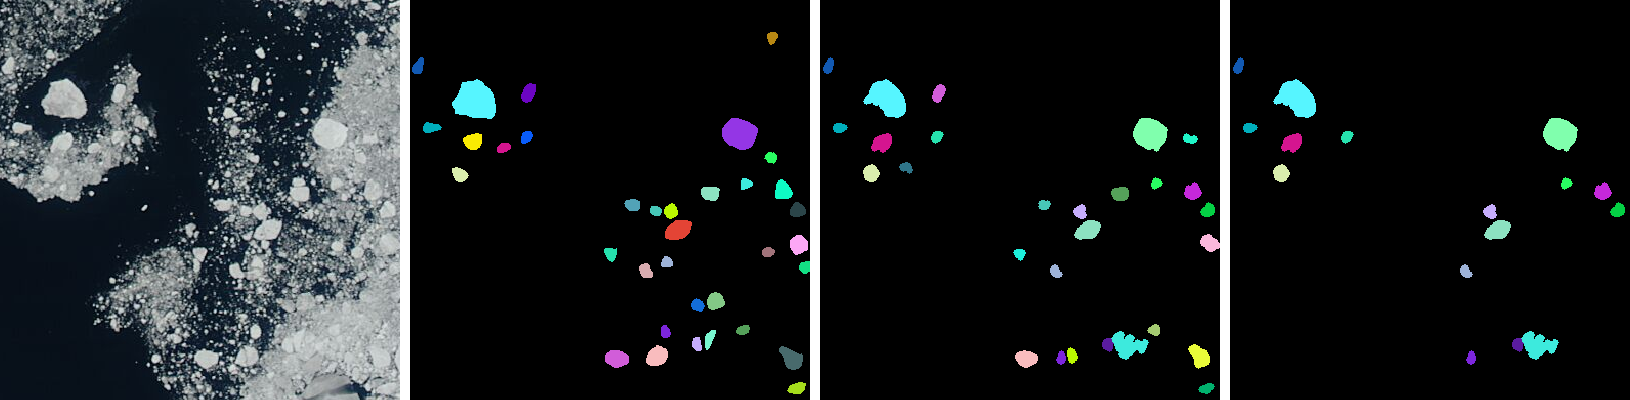

In [325]:
idx = 11
test_img = FSPipeline.assign_labels(kmeans_labels[idx], subset(df_pred[idx], :candidate)[:, :label]);
mosaicview(tc_imgs[idx], 
RGBA.(view_seg_random(SegmentedImage(fc_imgs[idx], labeled_floes[idx]))),
RGBA.(view_seg_random(SegmentedImage(fc_imgs[idx], kmeans_labels[idx]))),
RGBA.(view_seg_random(SegmentedImage(fc_imgs[idx], test_img))),
npad=10, fillvalue=RGBA(0, 0, 0, 0),
nrow=1)

In [84]:
# Adaptive workflow
@time begin
labeled_floes = label_components.(binary_floes)
df_true = extended_regionprops.(labeled_floes, coastal_buffers, cloud_masks, fc_imgs)
df_pred = extended_regionprops.(adapt_labels, coastal_buffers, cloud_masks, fc_imgs);

# Then add the relevant column
for (dft, dfp, lt, lp) in zip(df_true, df_pred, labeled_floes, adapt_labels)
    
    relevant_set = FSPipeline.get_relevant_set(dft, dfp, lt, lp)
    
    matched_labels = Int64[]
    for ll in values(relevant_set)
        for L in ll
            push!(matched_labels, L)
        end
    end
    
    matched_labels = unique(matched_labels);
    
    transform!(dfp, :label => ByRow(r -> r ∈ matched_labels) => :candidate)
    
end

df_pred_a = vcat(df_pred..., cols=:union);
df_pred_a[:, :solidity] = df_pred_a[:, :area] ./ df_pred_a[:, :convex_area];
save("../data/training_floe_properties_adapt.csv", df_pred_a)
end
nothing

 49.410986 seconds (1.13 G allocations: 36.292 GiB, 6.18% gc time, 0.66% compilation time: 24% of which was recompilation)


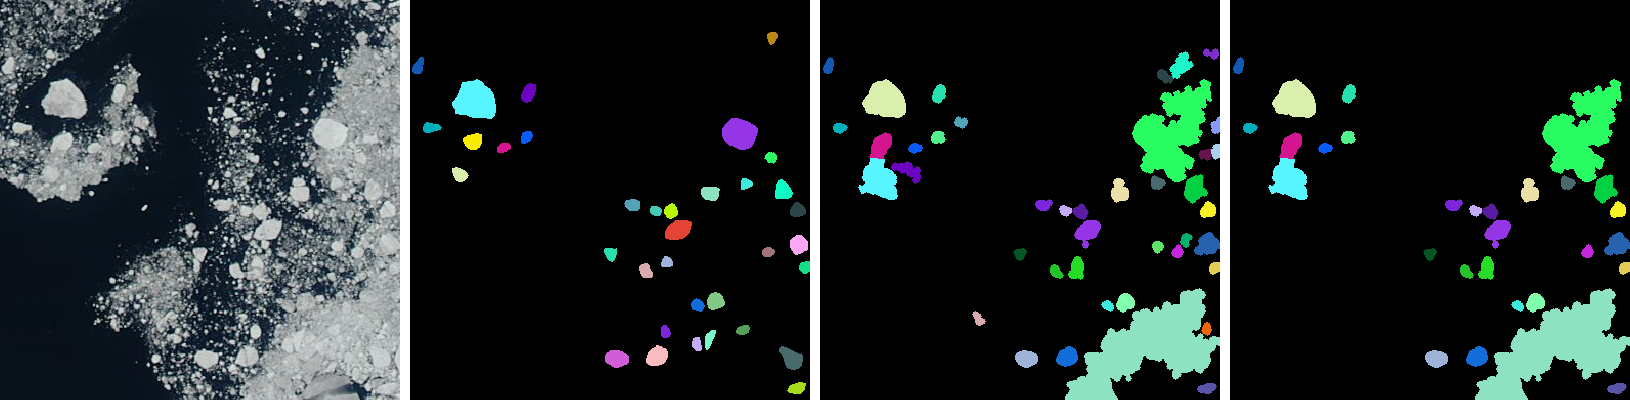

In [100]:
idx = 11
test_img = FSPipeline.assign_labels(adapt_labels[idx], subset(df_pred[idx], :candidate)[:, :label]);
mosaicview(tc_imgs[idx], 
RGBA.(view_seg_random(SegmentedImage(fc_imgs[idx], labeled_floes[idx]))),
RGBA.(view_seg_random(SegmentedImage(fc_imgs[idx], adapt_labels[idx]))),
RGBA.(view_seg_random(SegmentedImage(fc_imgs[idx], test_img))),
npad=10, fillvalue=RGBA(0, 0, 0, 0),
nrow=1)

724

In [142]:
### Fit model for k-means dataset
using GLM
using StatsBase
using Random

# Make "cloudy" column rather than using Float values
df_pred_k[:, :cloudy] = df_pred_k[:, :cloud_fraction] .> 0.5
df_pred_k[:, :length_scale] = df_pred_k[:, :area] .^ 0.5

# Select subset such that the classes are balanced between candidates and non-candidates

rng = Random.default_rng(300)
n = minimum(combine(groupby(df_pred_k, :candidate), nrow)[:, :nrow])
println("Drawing ", n, " samples of each class")

data_k = []
gdf = groupby(df_pred_k, :candidate)
for group in gdf
    subset_idx = StatsBase.sample(rng, 1:nrow(group), n; replace=false, ordered=true)
    push!(data_k, group[subset_idx, :])
end

train_df = vcat(data_k...)

fm = @formula(candidate ~ length_scale + circularity + b2_reflectance_mean + b2_bdry_contrast + cloudy)
logit_k = glm(fm, Float64.(train_df), Binomial(), LogitLink())

Drawing 724 samples of each class


StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

candidate ~ 1 + length_scale + circularity + b2_reflectance_mean + b2_bdry_contrast + cloudy

Coefficients:
──────────────────────────────────────────────────────────────────────────────────────
                          Coef.  Std. Error       z  Pr(>|z|)    Lower 95%   Upper 95%
──────────────────────────────────────────────────────────────────────────────────────
(Intercept)          -9.4051     0.828261    -11.36    <1e-29  -11.0285     -7.78174
length_scale          0.0357161  0.00666973    5.35    <1e-07    0.0226437   0.0487886
circularity           3.93643    0.582713      6.76    <1e-10    2.79433     5.07853
b2_reflectance_mean   7.57626    0.833514      9.09    <1e-19    5.9426      9.20992
b2_bdry_contrast      6.75339    0.75785       8.91   

217.67866225241278

In [141]:
# Make "cloudy" column rather than using Float values
df_pred_a[:, :cloudy] = df_pred_a[:, :cloud_fraction] .> 0.5
df_pred_a[:, :length_scale] = df_pred_a[:, :area] .^ 0.5

# Select subset such that the classes are balanced between candidates and non-candidates

rng = Random.default_rng(300)
n = minimum(combine(groupby(df_pred_a, :candidate), nrow)[:, :nrow])
println("Drawing ", n, " samples of each class")

data_a = []
gdf = groupby(df_pred_a, :candidate)
for group in gdf
    subset_idx = StatsBase.sample(rng, 1:nrow(group), n; replace=false, ordered=true)
    push!(data_a, group[subset_idx, :])
end

train_df = vcat(data_a...)

fm = @formula(candidate ~ length_scale + circularity + b2_reflectance_mean + b2_bdry_contrast + cloudy)
logit_a = glm(fm, Float64.(train_df), Binomial(), LogitLink())

Drawing 893 samples of each class


StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

candidate ~ 1 + length_scale + circularity + b2_reflectance_mean + b2_bdry_contrast + cloudy

Coefficients:
────────────────────────────────────────────────────────────────────────────────────
                          Coef.  Std. Error       z  Pr(>|z|)  Lower 95%   Upper 95%
────────────────────────────────────────────────────────────────────────────────────
(Intercept)          -6.89112    0.657419    -10.48    <1e-24  -8.17963   -5.6026
length_scale          0.0253853  0.00337317    7.53    <1e-13   0.018774   0.0319966
circularity           2.8223     0.483731      5.83    <1e-08   1.8742     3.77039
b2_reflectance_mean   6.03091    0.656218      9.19    <1e-19   4.74475    7.31708
b2_bdry_contrast      5.01997    0.569052      8.82    <1e-17   3.904

In [164]:
coefnames(logit_ak)

6-element Vector{String}:
 "(Intercept)"
 "length_scale"
 "circularity"
 "b2_reflectance_mean"
 "b2_bdry_contrast"
 "cloudy"

In [166]:
coef_dict = Dict(n => v for (v,n) in zip(coef(logit_ak), coefnames(logit_ak)))


Dict{String, Float64} with 6 entries:
  "circularity"         => 3.28796
  "cloudy"              => -2.21906
  "(Intercept)"         => -7.97726
  "length_scale"        => 0.0280868
  "b2_bdry_contrast"    => 5.75358
  "b2_reflectance_mean" => 6.75488

In [143]:
# Merged results
train_df = vcat(vcat(data_a...), vcat(data_k...))

# Select subset such that the classes are balanced between candidates and non-candidates
fm = @formula(candidate ~ length_scale + circularity + b2_reflectance_mean + b2_bdry_contrast + cloudy)
logit_ak = glm(fm, Float64.(train_df), Binomial(), LogitLink())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

candidate ~ 1 + length_scale + circularity + b2_reflectance_mean + b2_bdry_contrast + cloudy

Coefficients:
─────────────────────────────────────────────────────────────────────────────────────
                          Coef.  Std. Error       z  Pr(>|z|)   Lower 95%   Upper 95%
─────────────────────────────────────────────────────────────────────────────────────
(Intercept)          -7.97726    0.508005    -15.70    <1e-54  -8.97293    -6.98159
length_scale          0.0280868  0.00290848    9.66    <1e-21   0.0223863   0.0337873
circularity           3.28796    0.367918      8.94    <1e-18   2.56686     4.00907
b2_reflectance_mean   6.75488    0.510738     13.23    <1e-39   5.75385     7.75591
b2_bdry_contrast      5.75358    0.451546     12.74    <1e-36

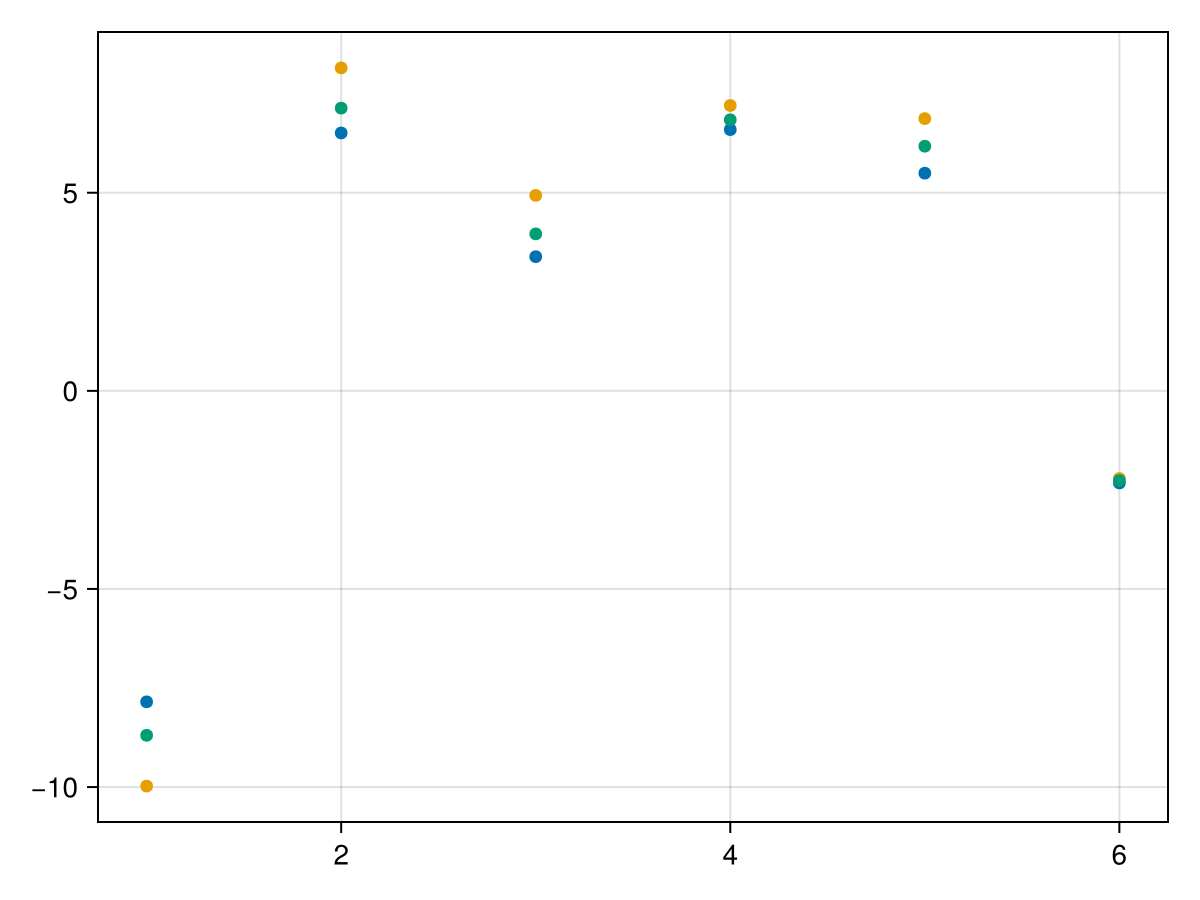

In [137]:
scatter(coef(logit_a))
scatter!(coef(logit_k))
scatter!(coef(logit_ak))
current_figure()

In [322]:
predicted = predict(logit_ak) .> 0.5
actual = train_df.candidate

tp = sum(predicted .&& actual)
fp = sum(predicted .&& .!actual)
tn = sum(.!predicted .&& .!actual)
fn = sum(.!predicted .&& actual)

println(" Actual:   0      1")
println("Predicted" )
println(" 0         ", tn, "    ", fn)
println(" 1         ", fp, "    ", tp)
println()
println("Recall:    ", round(tp / (tp + fn), digits=2))
println("Precision: ", round(tp / (tp + fp), digits=2))
println("Accuracy: ", round((tp + tn) / nrow(train_df), digits=2))
println("F-score: ", round((2*tp) / (2 * tp + fp + fn), digits=2))

 Actual:   0      1
Predicted
 0         1330    412
 1         287    1205

Recall:    0.75
Precision: 0.81
Accuracy: 0.78
F-score: 0.78


In [205]:
# The decision rule needs to be applied to each piece of information
coefs = Dict(
  "intercept"           => -7.97726,
  "circularity"         => 3.28796,
  "cloudy"              => -2.21906,
  "length_scale"        => 0.0280868,
  "b2_bdry_contrast"    => 5.75358,
  "b2_reflectance_mean" => 6.75488,
)
colnames = [x for x in keys(coefs)]
b = [x for x in values(coefs)]
train_df[:, :intercept] .= 1;
1 ./ (1 .+ exp.(-Matrix(train_df[:, colnames]) * b))

3234-element Vector{Float64}:
 0.057615423908901744
 0.040877367625694605
 0.012710932379686273
 0.011600199828172047
 0.05613204001197816
 0.189010707052985
 0.2365818248722226
 0.22807077836651987
 0.7063848312429043
 0.49725583013778296
 0.09180780969301817
 0.5004313936836469
 0.12814316357718128
 ⋮
 0.7741641190614217
 0.7895295663312472
 0.5919250771178961
 0.6233153530778679
 0.8708352181276623
 0.6374025426636997
 0.7227432635787282
 0.2991220582415947
 0.6426757206831027
 0.5135646486671542
 0.13854283278003363
 0.3292685482824977

In [308]:
# These are being added to the FSPipeline / updated
function keep_labels!(img_indexmap, labels_list)    
    indices = component_indices(img_indexmap)
    labels = filter(r -> r > 0, unique(img_indexmap))
    for L in labels
        if L ∉ labels_list
            img_indexmap[indices[L]] .= 0
        end
    end
end

function filter_floes!(
    img_indexmap,
    coastal_buffer_mask,
    cloud_mask,
    falsecolor_image;
    min_floe_size=100,
    max_floe_size=90_000,
    min_circularity=0.4,
    expand_radius=15,
    filter_function=LogisticFilterFunction, # needs to operate on a dataframe
    prob_threshold=0.3
)
    # 1. Remove objects which overlap the coastal mask
    overlap = unique(img_indexmap[coastal_buffer_mask])
    indices = component_indices(img_indexmap)
    for L in overlap
        img_indexmap[indices[L]] .= 0
    end

    # 2. Remove objects outside the specified size bounds
    remove_small_segments!(img_indexmap, min_floe_size)
    remove_large_segments!(img_indexmap, max_floe_size)

    # Return blank image if no floes remain
    maximum(img_indexmap) == 0 && return img_indexmap

    # 3. Remove objects with low probability scores using filter_function
    # TODO: Generalize to allow other function types, inputs

    results_df = regionprops_table(img_indexmap;
        properties=[:label, :area, :convex_area, :perimeter, :bbox, :centroid,
                    :major_axis_length, :minor_axis_length, :orientation]
    )

    results_df[:, :length_scale] = results_df[:, :area] .^ 0.5
    
    # TODO: add component_circularity to the regionprops options
    results_df[:, :circularity] = 4 * π * results_df[:, :area] ./ results_df[:, :perimeter] .^ 2

    labels = results_df[:, :label]
    cloud_fractions = Dict(L => mean(cloud_mask[indices[L]]) for L in labels)
    results_df[:, :cloud_fraction] = [cloud_fractions[L] for L in labels]
    results_df[:, :cloudy] = results_df[:, :cloud_fraction] .> 0.5
    b2 = green.(falsecolor_image)
    b2_means = Dict(L => mean(b2[indices[L]]) for L in labels)
    
    bdry_indexmap = expand_labels(img_indexmap, expand_radius) .- img_indexmap
    bdry_indices = component_indices(bdry_indexmap)
    bdry_labels = intersect(labels, unique(bdry_indexmap))
    b2_bdry_means = Dict(L => mean(b2[bdry_indices[L]]) for L in bdry_labels)
    for L ∈ labels
        if L ∉ bdry_labels
            push!(b2_bdry_means, L => 0)
        end
    end
    results_df[:, :b2_reflectance_mean] = [b2_means[L] for L in labels]
    results_df[:, :b2_reflectance_bdry_mean] = [b2_bdry_means[L] for L in labels]
    results_df[:, :b2_bdry_contrast] = results_df[:, :b2_reflectance_mean] .- results_df[:, :b2_reflectance_bdry_mean]
    results_df[:, :prob] .= filter_function(results_df)
    labels = subset(results_df, :prob => r -> r .> prob_threshold)[:, :label]
    keep_labels!(img_indexmap, labels)

    # enforce minimum circularity
    labels = subset(results_df, :circularity => r -> r .> min_circularity)[:, :label]
    keep_labels!(img_indexmap, labels)
end

"""
    LogisticRegressionFilter(df; coefs)

Compute the probability for each DataFrameRow using the logistic function
with coefficients defined in `coefs`. Names should include "intercept" and
names of columns in `df`.

"""
function LogisticRegressionFilter(df;
    coefs=Dict(
        "intercept"           => -7.97726,
        "circularity"         => 3.28796,
        "cloudy"              => -2.21906,
        "length_scale"        => 0.0280868,
        "b2_bdry_contrast"    => 5.75358,
        "b2_reflectance_mean" => 6.75488,
        )
    )
    colnames = [x for x in keys(coefs)]
    b = [x for x in values(coefs)]
    df[:, :intercept] .= 1;
    return 1 ./ (1 .+ exp.(-Matrix(df[:, colnames]) * b))
end


LogisticRegressionFilter

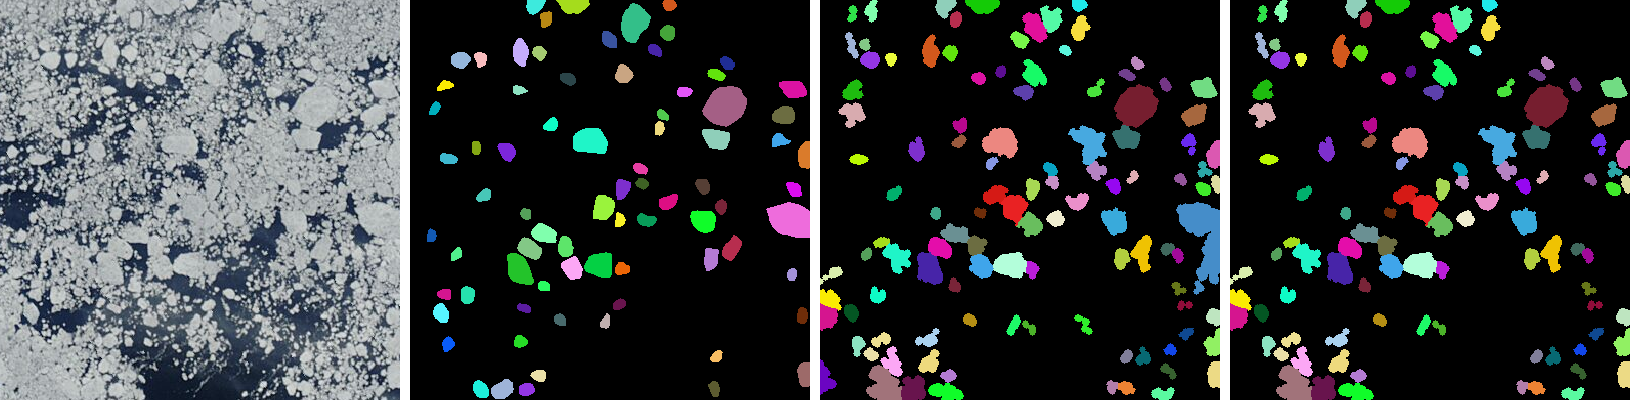

In [314]:
idx = 94

img_indexmap = deepcopy(adapt_labels[idx])

filter_floes!(
    img_indexmap,
    coastal_buffers[idx],
    cloud_masks[idx],
    fc_imgs[idx];
    min_floe_size=100,
    max_floe_size=90_000,
    expand_radius=15,
    filter_function=LogisticRegressionFilter # needs to operate on a dataframe
)

mosaicview(tc_imgs[idx], 
RGBA.(view_seg_random(SegmentedImage(fc_imgs[idx], labeled_floes[idx]))),
RGBA.(view_seg_random(SegmentedImage(fc_imgs[idx], adapt_labels[idx]))),
RGBA.(view_seg_random(SegmentedImage(fc_imgs[idx], img_indexmap))),
npad=10, fillvalue=RGBA(0, 0, 0, 0),
nrow=1)

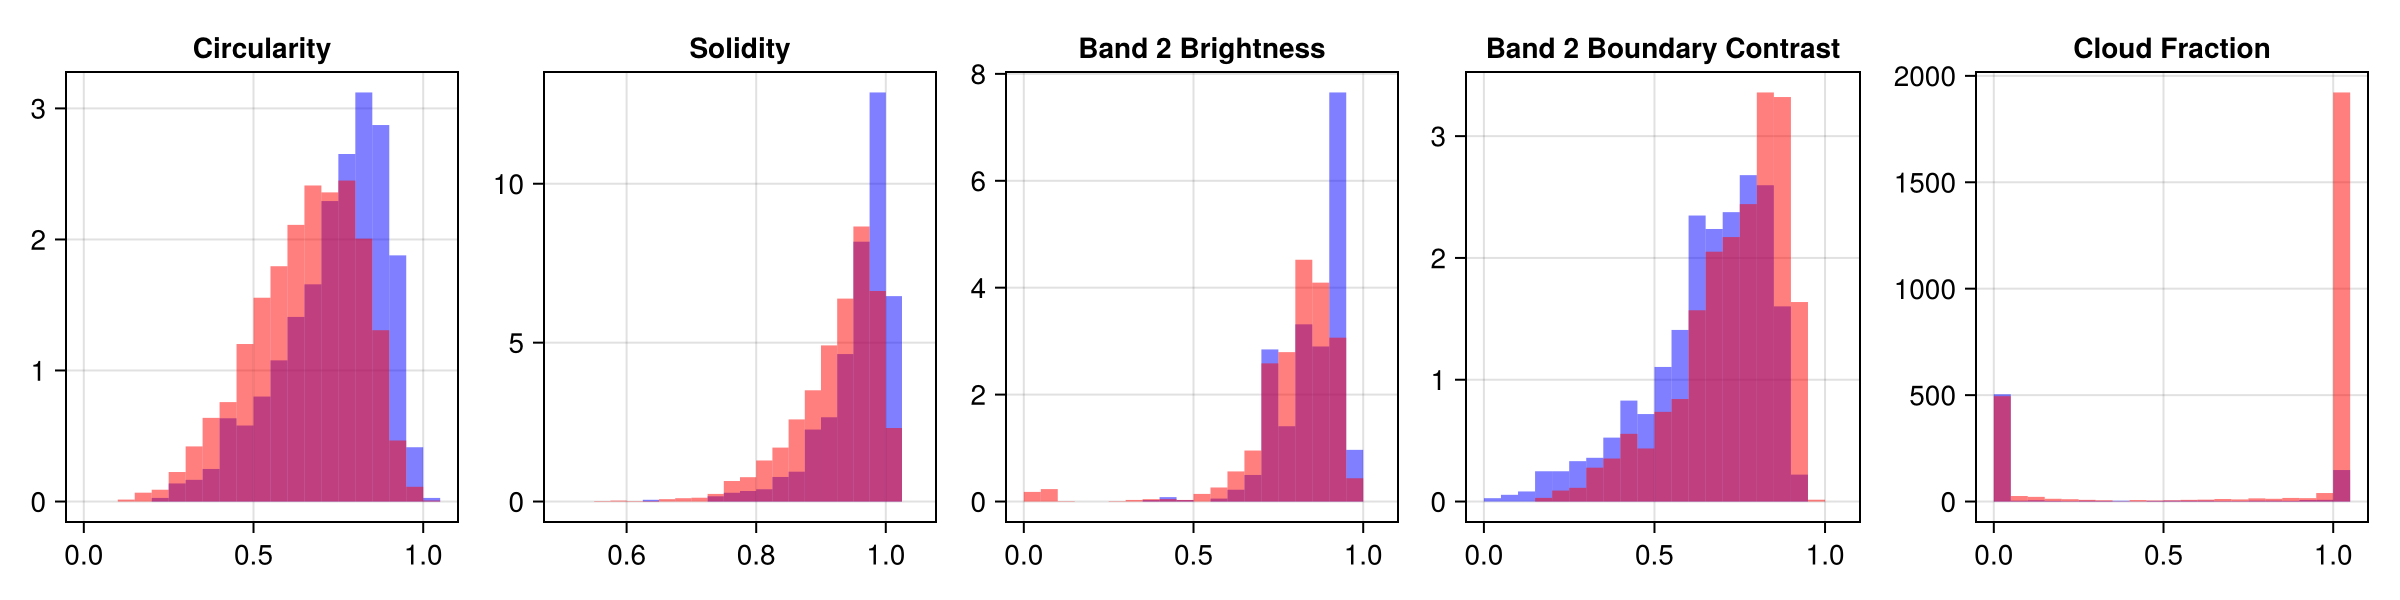

In [104]:
# Example of overlapping distributions
data_candidates = subset(df_pred_k, :candidate)
data_not_candidates = subset(df_pred_k, :candidate => r -> .! r)

f = Figure(size=(1200, 300))
ax = CairoMakie.Axis(f[1, 1], title="Circularity")
hist!(ax, data_candidates[:, :circularity], bins=0:0.05:1.05, color=(:blue, 0.5), normalization = :pdf)
hist!(ax, data_not_candidates[:, :circularity], bins=0:0.05:1.05, color=(:red, 0.5), normalization = :pdf)

ax = CairoMakie.Axis(f[1, 2], title="Solidity")
hist!(ax, data_candidates[:, :solidity], bins=0.5:0.025:1.05, color=(:blue, 0.5), normalization = :pdf)
hist!(ax, data_not_candidates[:, :solidity], bins=0.5:0.025:1.05, color=(:red, 0.5), normalization = :pdf)

ax = CairoMakie.Axis(f[1, 3], title="Band 2 Brightness")
hist!(ax, data_candidates[:, :b2_reflectance_mean], bins=0:0.05:1.05, color=(:blue, 0.5), normalization = :pdf)
hist!(ax, data_not_candidates[:, :b2_reflectance_mean], bins=0:0.05:1.05, color=(:red, 0.5), normalization = :pdf)

hist!(ax, data_candidates[:, :b2_reflectance_bdry_mean], bins=0:0.05:1.05, color=(:blue, 0.5), normalization = :pdf)
ax = CairoMakie.Axis(f[1, 4], title="Band 2 Boundary Contrast")
hist!(ax, data_not_candidates[:, :b2_reflectance_bdry_mean], bins=0:0.05:1.05, color=(:red, 0.5), normalization = :pdf)

ax = CairoMakie.Axis(f[1, 5], title="Cloud Fraction")
hist!(ax, data_candidates[:, :cloud_fraction], bins=0:0.05:1.05, color=(:blue, 0.5))
hist!(ax, data_not_candidates[:, :cloud_fraction], bins=0:0.05:1.05, color=(:red, 0.5))

current_figure()


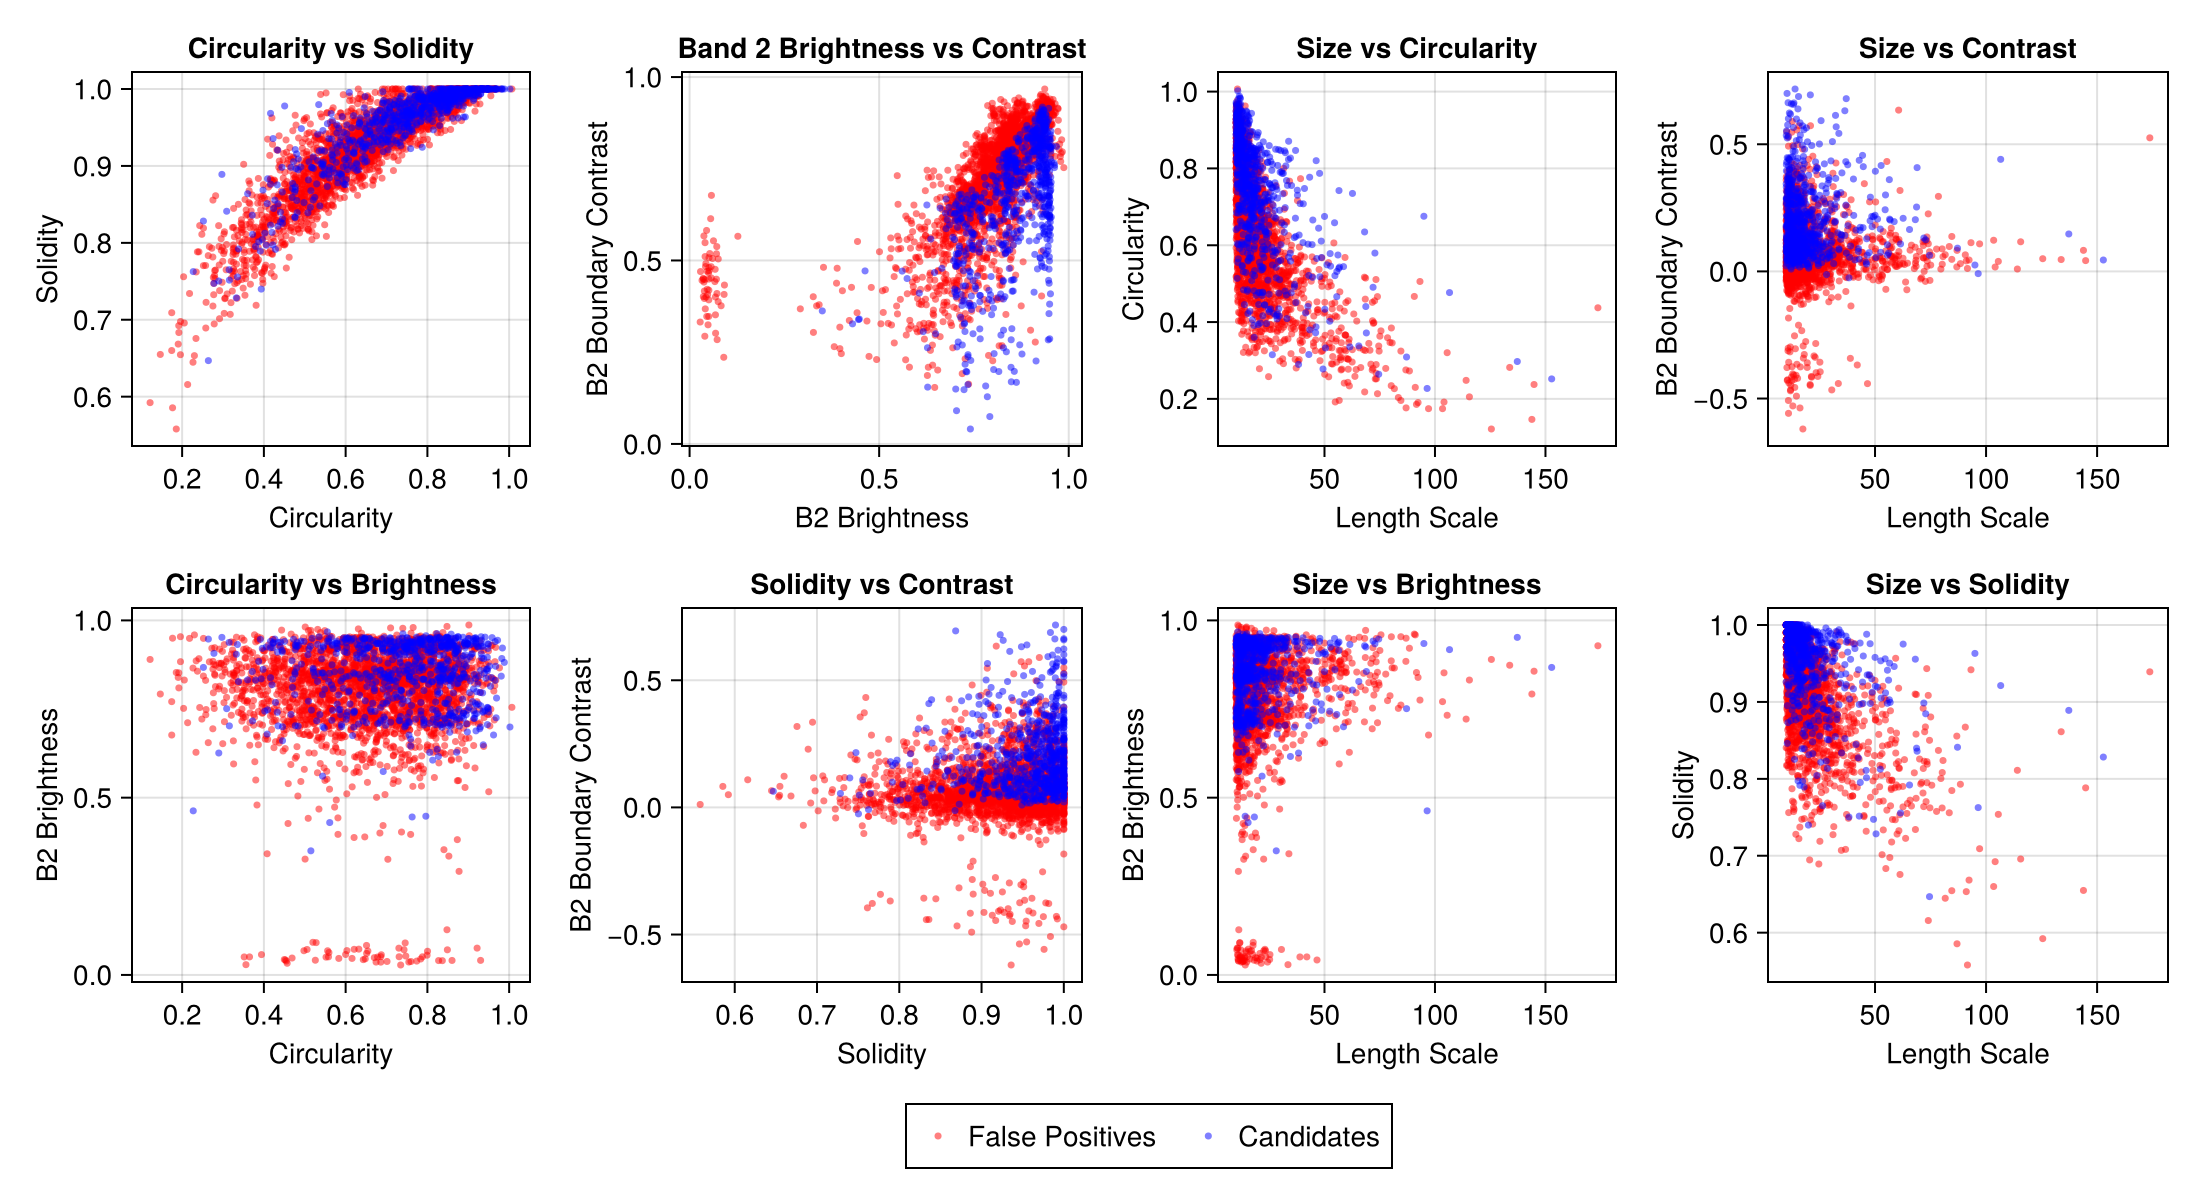

In [332]:
f = Figure(size=(1100, 600))
ax = CairoMakie.Axis(f[1, 1], title="Circularity vs Solidity", xlabel="Circularity", ylabel="Solidity")

scatter!(ax, subset(df_pred_all, :candidate => r -> .! r)[:, :circularity],
             subset(df_pred_all, :candidate => r -> .! r)[:, :solidity],
    color=(:red, 0.5), markersize=5)

scatter!(ax, subset(df_pred_all, :candidate)[:, :circularity],
             subset(df_pred_all, :candidate)[:, :solidity],
    color=(:blue, 0.5), markersize=5)


ax = CairoMakie.Axis(f[1, 2], title="Band 2 Brightness vs Contrast", xlabel="B2 Brightness", ylabel="B2 Boundary Contrast")

scatter!(ax, subset(df_pred_all, :candidate => r -> .! r)[:, :b2_reflectance_mean],
             subset(df_pred_all, :candidate => r -> .! r)[:, :b2_reflectance_bdry_mean],
    color=(:red, 0.5), markersize=5)

scatter!(ax, subset(df_pred_all, :candidate)[:, :b2_reflectance_mean],
             subset(df_pred_all, :candidate)[:, :b2_reflectance_bdry_mean],
    color=(:blue, 0.5), markersize=5)

ax = CairoMakie.Axis(f[1, 3], title="Size vs Circularity", xlabel="Length Scale", ylabel="Circularity")
scatter!(ax, subset(df_pred_all, :candidate => r -> .! r)[:, :area] .^ 0.5,
             subset(df_pred_all, :candidate => r -> .! r)[:, :circularity],
    color=(:red, 0.5), markersize=5)

scatter!(ax, subset(df_pred_all, :candidate)[:, :area] .^ 0.5,
             subset(df_pred_all, :candidate)[:, :circularity],
    color=(:blue, 0.5), markersize=5)


ax = CairoMakie.Axis(f[1, 4], title="Size vs Contrast", xlabel="Length Scale", ylabel="B2 Boundary Contrast")

scatter!(ax, subset(df_pred_all, :candidate => r -> .! r)[:, :area] .^ 0.5,
             subset(df_pred_all, :candidate => r -> .! r)[:, :b2_bdry_contrast],
    color=(:red, 0.5), markersize=5)

scatter!(ax, subset(df_pred_all, :candidate)[:, :area] .^ 0.5,
             subset(df_pred_all, :candidate)[:, :b2_bdry_contrast],
    color=(:blue, 0.5), markersize=5)


ax = CairoMakie.Axis(f[2, 1], title="Circularity vs Brightness", xlabel="Circularity", ylabel="B2 Brightness")

scatter!(ax, subset(df_pred_all, :candidate => r -> .! r)[:, :circularity],
             subset(df_pred_all, :candidate => r -> .! r)[:, :b2_reflectance_mean],
    color=(:red, 0.5), markersize=5)

scatter!(ax, subset(df_pred_all, :candidate)[:, :circularity],
             subset(df_pred_all, :candidate)[:, :b2_reflectance_mean],
    color=(:blue, 0.5), markersize=5)


ax = CairoMakie.Axis(f[2, 2], title="Solidity vs Contrast", xlabel="Solidity", ylabel="B2 Boundary Contrast")

scatter!(ax, subset(df_pred_all, :candidate => r -> .! r)[:, :solidity],
             subset(df_pred_all, :candidate => r -> .! r)[:, :b2_bdry_contrast],
    color=(:red, 0.5), markersize=5)

scatter!(ax, subset(df_pred_all, :candidate)[:, :solidity],
             subset(df_pred_all, :candidate)[:, :b2_bdry_contrast],
    color=(:blue, 0.5), markersize=5)

ax = CairoMakie.Axis(f[2, 3], title="Size vs Brightness", xlabel="Length Scale", ylabel="B2 Brightness")
scatter!(ax, subset(df_pred_all, :candidate => r -> .! r)[:, :area] .^ 0.5,
             subset(df_pred_all, :candidate => r -> .! r)[:, :b2_reflectance_mean],
    color=(:red, 0.5), markersize=5)

scatter!(ax, subset(df_pred_all, :candidate)[:, :area] .^ 0.5,
             subset(df_pred_all, :candidate)[:, :b2_reflectance_mean],
    color=(:blue, 0.5), markersize=5)


ax = CairoMakie.Axis(f[2, 4], title="Size vs Solidity", xlabel="Length Scale", ylabel="Solidity")

a1 = scatter!(ax, subset(df_pred_all, :candidate => r -> .! r)[:, :area] .^ 0.5,
             subset(df_pred_all, :candidate => r -> .! r)[:, :solidity],
    color=(:red, 0.5), markersize=5)

a2 = scatter!(ax, subset(df_pred_all, :candidate)[:, :area] .^ 0.5,
             subset(df_pred_all, :candidate)[:, :solidity],
    color=(:blue, 0.5), markersize=5)

Legend(f[3, 2:3], [a1, a2], ["False Positives", "Candidates"], orientation = :horizontal)

save("../figures/floe_filter_all.png", f)
current_figure()

The joint distributions for circularity/solidity, brightness and contrast, size vs circularity and size vs contrast all show distinct patterns however simple thresholds are not sufficient for distinguishing the two. Before we jump to the logistic regression function, let's take a look at the difference between clear-sky and cloudy cases. For the k-means approach, there are very few cloudy cases, since it requires clear-sky regions to identify the ice floe cluster. The cloud fraction is nearly bimodal, so we split at 50%.